# Setup

In [2]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import pandas as pd
import numpy as np

from astropy.constants import R_sun, L_sun, sigma_sb, G, M_earth, R_earth, R

import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter
import matplotlib.animation as animation
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

import tensorflow as tf

from geexhp import datasetup as dset
from geexhp import datavis as dvis
from geexhp import datagen

dvis.configure_matplotlib()

E0000 00:00:1771787864.854328  310474 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771787864.885545  310474 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771787864.959246  310474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771787864.959281  310474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771787864.959285  310474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771787864.959287  310474 computation_placer.cc:177] computation placer already registered. Please check linka

# Looking some data

In [41]:
dg = datagen.DataGen(stage="modern")
dg.generator(0, 5, random_atm=False, output_file="test_modern")

Error processing planet index 1: Exhausted all attempts to find a planet configuration that can retain a stable atmosphere with liquid water.. Skipping...
Error processing planet index 2: Exhausted all attempts to find a planet configuration that can retain a stable atmosphere with liquid water.. Skipping...
>> Range 0-5 done in 0:00:09.408477. Saved to data/test_modern.parquet.


In [45]:
df = pd.read_parquet("data/test_modern.parquet")
# data = df.iloc[0][df.columns[:-24]].to_dict()
# result = "\n".join([f"<{key}>{value}" for key, value in data.items()])

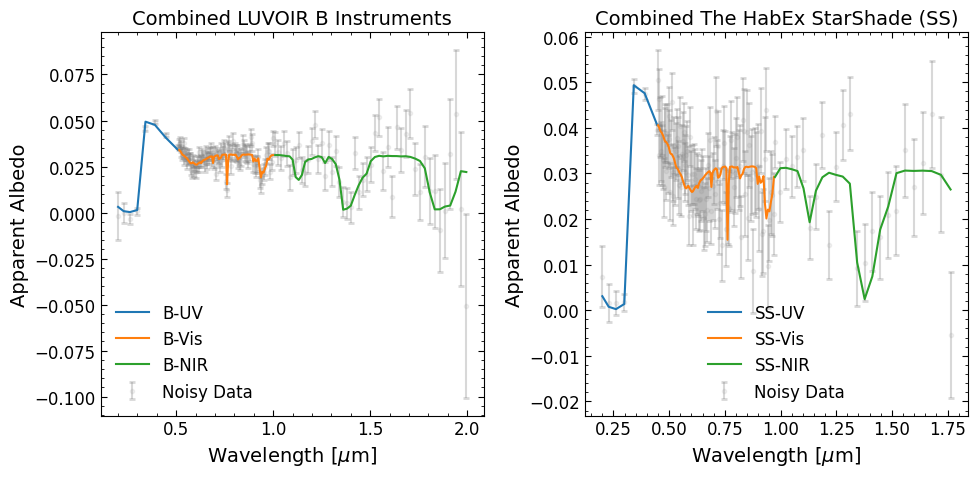

In [47]:
dvis.plot_spectrum(df, index=1, noise=True)
plt.show()

In [48]:
os.remove("data/test_modern.parquet")
os.rmdir("data")

# Loading data (tfrecord)


In [11]:
tfrecord_file = "../data/all.tfrecord"  # This file has only cases with SNR PCLT > 3.0

feature_description = {
    "NOISY_ALBEDO_B-NIR": tf.io.VarLenFeature(tf.float32),
    "NOISY_ALBEDO_B-UV": tf.io.VarLenFeature(tf.float32),
    "NOISY_ALBEDO_B-Vis": tf.io.VarLenFeature(tf.float32),
    "NOISY_ALBEDO_SS-NIR": tf.io.VarLenFeature(tf.float32),
    "NOISY_ALBEDO_SS-UV": tf.io.VarLenFeature(tf.float32),
    "NOISY_ALBEDO_SS-Vis": tf.io.VarLenFeature(tf.float32),
    # Clean albedo (model line)
    "ALBEDO_B-NIR": tf.io.VarLenFeature(tf.float32),
    "ALBEDO_B-UV": tf.io.VarLenFeature(tf.float32),
    "ALBEDO_B-Vis": tf.io.VarLenFeature(tf.float32),
    "ALBEDO_SS-NIR": tf.io.VarLenFeature(tf.float32),
    "ALBEDO_SS-UV": tf.io.VarLenFeature(tf.float32),
    "ALBEDO_SS-Vis": tf.io.VarLenFeature(tf.float32),
    # Noise (error bars)
    "NOISE_B-NIR": tf.io.VarLenFeature(tf.float32),
    "NOISE_B-UV": tf.io.VarLenFeature(tf.float32),
    "NOISE_B-Vis": tf.io.VarLenFeature(tf.float32),
    "NOISE_SS-NIR": tf.io.VarLenFeature(tf.float32),
    "NOISE_SS-UV": tf.io.VarLenFeature(tf.float32),
    "NOISE_SS-Vis": tf.io.VarLenFeature(tf.float32),
    "OBJECT-RADIUS-REL-EARTH": tf.io.FixedLenFeature([], tf.float32),
    "OBJECT-GRAVITY": tf.io.FixedLenFeature([], tf.float32),
    "ATMOSPHERE-TEMPERATURE": tf.io.FixedLenFeature([], tf.float32),
    "ATMOSPHERE-PRESSURE": tf.io.FixedLenFeature([], tf.float32),
    "Earth_type": tf.io.FixedLenFeature([], tf.string),
    "CH4": tf.io.FixedLenFeature([], tf.float32),
    "CO2": tf.io.FixedLenFeature([], tf.float32),
    "H2O": tf.io.FixedLenFeature([], tf.float32),
    "N2": tf.io.FixedLenFeature([], tf.float32),
    "O2": tf.io.FixedLenFeature([], tf.float32),
    "O3": tf.io.FixedLenFeature([], tf.float32),
    "OBJECT-STAR-TYPE": tf.io.FixedLenFeature([], tf.string),
    "GEOMETRY-OBS-ALTITUDE": tf.io.FixedLenFeature([], tf.float32),
}


def parse_example(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    parsed = {
        k: (tf.sparse.to_dense(v) if isinstance(v, tf.SparseTensor) else v)
        for k, v in parsed.items()
    }
    return parsed


ds = tf.data.TFRecordDataset(tfrecord_file).map(parse_example)

rows = []
for ex in ds:
    row = {}
    for k, v in ex.items():
        val = v.numpy()
        if isinstance(val, bytes):
            row[k] = val.decode("utf-8")
        elif np.ndim(val) == 0:
            row[k] = val.item()
        else:
            row[k] = val.tolist()
    rows.append(row)

df = pd.DataFrame(rows)
df.head()

,ALBEDO_B-NIR,ALBEDO_B-UV,ALBEDO_B-Vis,ALBEDO_SS-NIR,ALBEDO_SS-UV,ALBEDO_SS-Vis,NOISE_B-NIR,NOISE_B-UV,NOISE_B-Vis,NOISE_SS-NIR,...,CO2,Earth_type,GEOMETRY-OBS-ALTITUDE,H2O,N2,O2,O3,OBJECT-GRAVITY,OBJECT-RADIUS-REL-EARTH,OBJECT-STAR-TYPE
0,"[0.018999246880412102, 0.01897798478603363, 0....","[0.0005497404490597546, 0.00011227169306948781...","[0.013182643800973892, 0.0123363072052598, 0.0...","[0.017396358773112297, 0.01882745325565338, 0....","[0.0005497404490597546, 0.00011227169306948781...","[0.031748998910188675, 0.03140556439757347, 0....","[0.0006112860282883048, 0.0006217000191099942,...","[0.0016271499916911125, 0.0007454860024154186,...","[0.0004028360126540065, 0.0004020360065624118,...","[0.0006457979907281697, 0.0007129680016078055,...",...,0.000778,modern,5.115456,0.000262,0.359465,0.639486,7.854622e-06,11.122946,1.083253,F
1,"[0.04986875131726265, 0.08183590322732925, 0.1...","[0.015051324851810932, 0.21071192622184753, 0....","[0.12561263144016266, 0.1254708617925644, 0.12...","[0.06575043499469757, 0.04750349745154381, 0.0...","[0.015051324851810932, 0.21071194112300873, 0....","[0.1291193962097168, 0.12888383865356445, 0.12...","[0.006902089808136225, 0.007058850023895502, 0...","[0.008332299999892712, 0.005119009874761105, 0...","[0.0034866200294345617, 0.0034976298920810223,...","[0.006269000004976988, 0.007189080119132996, 0...",...,0.138967,archean,8.825589,0.002687,0.824734,0.000000,0.000000e+00,5.970667,0.738624,F
2,"[0.01903710328042507, 0.01904383860528469, 0.0...","[0.04250362887978554, 0.11256221681833267, 0.0...","[0.03592939302325249, 0.035506054759025574, 0....","[0.01787896268069744, 0.018865730613470078, 0....","[0.04250362887978554, 0.11256223171949387, 0.0...","[0.04541084170341492, 0.04484196752309799, 0.0...","[0.0014198600547388196, 0.001440280000679195, ...","[0.005436279810965061, 0.002608570037409663, 0...","[0.0009107519872486591, 0.0009101810283027589,...","[0.001341119990684092, 0.001554689952172339, 0...",...,0.009593,archean,5.959427,0.000177,0.990173,0.000000,0.000000e+00,13.797438,1.223046,F
3,"[0.08930347859859467, 0.08952652662992477, 0.0...","[0.00552759412676096, 0.001738170743919909, 0....","[0.08873900771141052, 0.08787403255701065, 0.0...","[0.07458849251270294, 0.08886810392141342, 0.0...","[0.00552759412676096, 0.0017381708603352308, 0...","[0.102410227060318, 0.10201787203550339, 0.101...","[0.0006586199742741883, 0.0006698910146951675,...","[0.001048840000294149, 0.0005679429741576314, ...","[0.000495161977596581, 0.0004952540039084852, ...","[0.0006911489763297141, 0.0007699609850533307,...",...,0.000136,modern,5.404133,0.000806,0.848311,0.150746,9.141867e-07,13.251148,1.212244,F
4,"[0.10660474002361298, 0.10673989355564117, 0.1...","[0.000514260376803577, 5.294600487104617e-05, ...","[0.01630174182355404, 0.014311135746538639, 0....","[0.09677033126354218, 0.10472313314676285, 0.1...","[0.000514260376803577, 5.294600850902498e-05, ...","[0.0923829898238182, 0.09078065305948257, 0.08...","[0.0018244599923491478, 0.001859599957242608, ...","[0.003573270048946142, 0.0016288700280711055, ...","[0.0009768049931153655, 0.000975827977526933, ...","[0.0017974800430238247, 0.0019787598866969347,...",...,0.000750,modern,7.771489,0.000889,0.595802,0.402510,4.257270e-05,9.018781,0.949600,F


In [12]:
df["Earth_type"].value_counts()

Earth_type
proterozoic    38754
modern         35372
archean        34120
Name: count, dtype: int64

# Figure 1

In [4]:
# Predefined wavelength arrays
WAVELENGTHS = {
    "B-UV": np.array(
        [
            0.2,
            0.22857143,
            0.26122449,
            0.29854227,
            0.34119117,
            0.38993277,
            0.44563745,
            0.50929994,
        ]
    ),
    "B-Vis": np.array(
        [
            0.515,
            0.51867857,
            0.52238342,
            0.52611473,
            0.52987269,
            0.5366575,
            0.53746934,
            0.5413084,
            0.54517489,
            0.549069,
            0.55299092,
            0.55694085,
            0.560919,
            0.56492557,
            0.56896075,
            0.57302475,
            0.57711779,
            0.58124006,
            0.58539177,
            0.58957314,
            0.59378438,
            0.5980257,
            0.60229731,
            0.60659943,
            0.61093229,
            0.61529609,
            0.61969106,
            0.62411742,
            0.62857541,
            0.63306523,
            0.63758712,
            0.64214132,
            0.64672804,
            0.65134753,
            0.65600001,
            0.66068572,
            0.66540491,
            0.6701578,
            0.67494464,
            0.67976568,
            0.68462114,
            0.6895113,
            0.69443638,
            0.69939664,
            0.70439233,
            0.7094237,
            0.71449101,
            0.71959452,
            0.72473448,
            0.72991116,
            0.73512481,
            0.7403757,
            0.7456641,
            0.75099027,
            0.75635448,
            0.76175702,
            0.76719814,
            0.77267812,
            0.77819725,
            0.78375581,
            0.78935406,
            0.7949923,
            0.80067082,
            0.8063899,
            0.81214983,
            0.8179509,
            0.8237934,
            0.82967764,
            0.83560391,
            0.84157251,
            0.84758374,
            0.85363791,
            0.85973532,
            0.86587629,
            0.87206112,
            0.87829013,
            0.88456363,
            0.89088194,
            0.89724539,
            0.90365428,
            0.91010895,
            0.91660973,
            0.92315694,
            0.92975092,
            0.936392,
            0.94308052,
            0.9498168,
            0.95660121,
            0.96343408,
            0.97031575,
            0.97724657,
            0.98422691,
            0.9912571,
            0.99833751,
        ]
    ),
    "B-NIR": np.array(
        [
            1.01,
            1.02442857,
            1.03906327,
            1.05390703,
            1.06896284,
            1.08423374,
            1.09972279,
            1.11543312,
            1.13136788,
            1.14753028,
            1.16392356,
            1.18055104,
            1.19741606,
            1.214522,
            1.23187232,
            1.24947049,
            1.26732007,
            1.28542464,
            1.30378785,
            1.32241339,
            1.34130501,
            1.36046651,
            1.37990175,
            1.39961463,
            1.41960913,
            1.43988926,
            1.4604591,
            1.48132281,
            1.50248456,
            1.52394862,
            1.54571932,
            1.56780102,
            1.59019818,
            1.6129153,
            1.63595694,
            1.65932776,
            1.68303244,
            1.70707576,
            1.73146256,
            1.75619774,
            1.78128628,
            1.80673322,
            1.8325437,
            1.85872289,
            1.88527608,
            1.91220859,
            1.93952586,
            1.96723337,
            1.9953367,
        ]
    ),
    "SS-UV": np.array(
        [0.2, 0.22857143, 0.26122449, 0.29854227, 0.34119117, 0.38993277, 0.44563745]
    ),
    "SS-Vis": np.array(
        [
            0.45,
            0.45321429,
            0.45645153,
            0.4597119,
            0.46299556,
            0.46630267,
            0.4696334,
            0.47298792,
            0.47636641,
            0.47976903,
            0.48319595,
            0.48664735,
            0.4901234,
            0.49362428,
            0.49715017,
            0.50070124,
            0.50427768,
            0.50787966,
            0.51150737,
            0.515161,
            0.51884072,
            0.52254673,
            0.5262792,
            0.53003834,
            0.53382433,
            0.53763736,
            0.54147762,
            0.54534532,
            0.54924065,
            0.55316379,
            0.55711496,
            0.56109436,
            0.56510217,
            0.56913862,
            0.57320389,
            0.57729821,
            0.58142176,
            0.58557478,
            0.58975745,
            0.59397001,
            0.59821265,
            0.6024856,
            0.60678907,
            0.61112327,
            0.61548844,
            0.61988479,
            0.62431253,
            0.62877191,
            0.63326314,
            0.63778645,
            0.64234206,
            0.64693022,
            0.65155115,
            0.65620509,
            0.66089227,
            0.66561293,
            0.6703673,
            0.67515564,
            0.67997818,
            0.68483517,
            0.68972685,
            0.69465347,
            0.69961528,
            0.70461253,
            0.70964548,
            0.71471438,
            0.71981948,
            0.72496105,
            0.73013934,
            0.73535462,
            0.74060715,
            0.7458972,
            0.75122504,
            0.75659093,
            0.76199516,
            0.76743798,
            0.77291968,
            0.77844053,
            0.78400082,
            0.78960083,
            0.79524083,
            0.80092113,
            0.80664199,
            0.81240372,
            0.8182066,
            0.82405094,
            0.82993701,
            0.83586514,
            0.8418356,
            0.84784871,
            0.85390477,
            0.86000409,
            0.86614698,
            0.87233374,
            0.8785647,
            0.88484016,
            0.89116045,
            0.89752588,
            0.90393678,
            0.91039347,
            0.91689628,
            0.92344554,
            0.93004158,
            0.93668473,
            0.94337534,
            0.95011373,
            0.95690026,
            0.96373526,
            0.97061909,
        ]
    ),
    "SS-NIR": np.array(
        [
            0.975,
            0.999375,
            1.02435937,
            1.04996836,
            1.07621757,
            1.10312301,
            1.13070108,
            1.15896861,
            1.18794282,
            1.2176414,
            1.24808243,
            1.27928449,
            1.3112666,
            1.34404827,
            1.37764947,
            1.41209071,
            1.44739298,
            1.4835778,
            1.52066725,
            1.55868393,
            1.59765103,
            1.63759231,
            1.67853211,
            1.72049542,
            1.7635078,
        ]
    ),
}

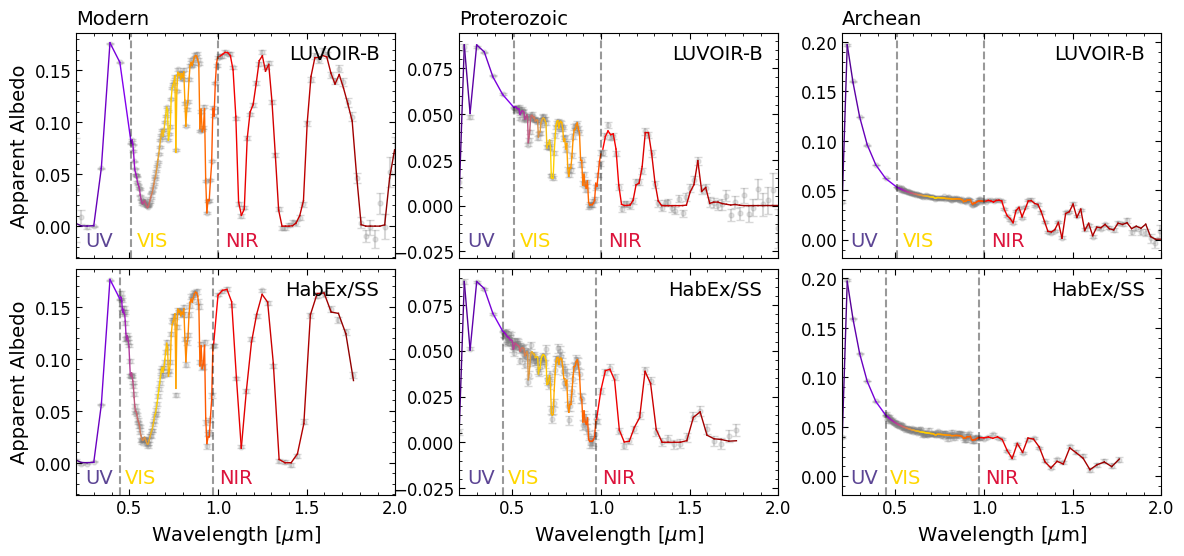

In [10]:
earth_types = ["modern", "proterozoic", "archean"]
sample_indices = {"modern": 50, "proterozoic": 52, "archean": 54}
random_seed = 42
output_path = "../images/sample_spectra.pdf"

rng = np.random.default_rng(random_seed)

earth_col = "Earth_type"

gradient_maps = {
    "B-UV": ["#4B0082", "#8B00FF"],
    "B-Vis": ["#9400D3", "#FFD700", "#FF4500"],
    "B-NIR": ["#FF0000", "#8B0000"],
    "SS-UV": ["#4B0082", "#8B00FF"],
    "SS-Vis": ["#9400D3", "#FFD700", "#FF4500"],
    "SS-NIR": ["#FF0000", "#8B0000"],
}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 6), sharex=True, sharey="col")

for j, earth_type in enumerate(earth_types):
    sub = df[df[earth_col].str.lower() == earth_type].reset_index(drop=True)

    if sample_indices is not None and earth_type in sample_indices:
        idx = min(sample_indices[earth_type], len(sub) - 1)
    else:
        idx = rng.integers(0, len(sub))

    row = sub.iloc[idx]

    for row_i, instruments in enumerate(
        [["B-UV", "B-Vis", "B-NIR"], ["SS-UV", "SS-Vis", "SS-NIR"]]
    ):
        ax = axes[row_i, j]
        noisy_label_added = False

        for instrument in instruments:
            wl = np.asarray(WAVELENGTHS[instrument])
            albedo = np.asarray(row[f"ALBEDO_{instrument}"])
            noisy = np.asarray(row[f"NOISY_ALBEDO_{instrument}"])
            noise = np.asarray(row[f"NOISE_{instrument}"])

            n = min(len(wl), len(albedo), len(noisy), len(noise))
            wl, albedo, noisy, noise = wl[:n], albedo[:n], noisy[:n], noise[:n]

            lbl = "Noisy Data" if not noisy_label_added else "_nolegend_"
            noisy_label_added = True

            _, caps, bars = ax.errorbar(
                wl,
                noisy,
                yerr=noise,
                fmt=".",
                color="tab:gray",
                alpha=0.2,
                markersize=7,
                capsize=3,
                capthick=1,
                label=lbl,
                zorder=1,
            )
            [b.set_alpha(0.3) for b in bars]
            [c.set_alpha(0.3) for c in caps]

            cmap = mcolors.LinearSegmentedColormap.from_list(
                f"{instrument}_gradient", gradient_maps[instrument], N=max(n, 2)
            )
            for k in range(n - 1):
                ax.plot(
                    wl[k : k + 2],
                    albedo[k : k + 2],
                    color=cmap(k / max(n - 1, 1)),
                    lw=1,
                    zorder=2,
                )

        ax.set_xlim(0.2, 2.0)
        if row_i == 0:
            ax.axvline(WAVELENGTHS["B-UV"][-1], color="k", linestyle="--", alpha=0.4)
            ax.axvline(WAVELENGTHS["B-Vis"][-1], color="k", linestyle="--", alpha=0.4)
            ax.text(
                0.95, 0.95, "LUVOIR-B", transform=ax.transAxes, ha="right", va="top"
            )
            ax.set_title(earth_type.capitalize(), loc="left")
            ax.text(
                0.07, 0.05, "UV", color="#5C4594", transform=ax.transAxes, ha="center"
            )
            ax.text(
                0.24, 0.05, "VIS", color="#FFD700", transform=ax.transAxes, ha="center"
            )
            ax.text(
                0.52, 0.05, "NIR", color="#DC143C", transform=ax.transAxes, ha="center"
            )
            ax.set_xlabel("")
        else:
            ax.axvline(WAVELENGTHS["SS-UV"][-1], color="k", linestyle="--", alpha=0.4)
            ax.axvline(WAVELENGTHS["SS-Vis"][-1], color="k", linestyle="--", alpha=0.4)
            ax.text(
                0.95, 0.95, "HabEx/SS", transform=ax.transAxes, ha="right", va="top"
            )
            ax.text(
                0.07, 0.05, "UV", color="#5C4594", transform=ax.transAxes, ha="center"
            )
            ax.text(
                0.20, 0.05, "VIS", color="#FFD700", transform=ax.transAxes, ha="center"
            )
            ax.text(
                0.50, 0.05, "NIR", color="#DC143C", transform=ax.transAxes, ha="center"
            )
            ax.set_xlabel("Wavelength [$\\mu$m]")

        if j == 0:
            ax.set_ylabel("Apparent Albedo")
        else:
            ax.set_ylabel("")

plt.subplots_adjust(wspace=0.2, hspace=0.05)
plt.savefig(output_path, bbox_inches="tight", dpi=300)
plt.show()

# Figure 2

In [15]:
def _kM_no_trailing_decimal(x, pos=None):
    x = float(x)
    if abs(x) < 1000:
        return f"{int(round(x))}"
    if abs(x) < 1_000_000:
        v = x / 1000.0
        s = f"{v:.1f}".rstrip("0").rstrip(".")
        return f"{s}k"
    v = x / 1_000_000.0
    s = f"{v:.1f}".rstrip("0").rstrip(".")
    return f"{s}M"

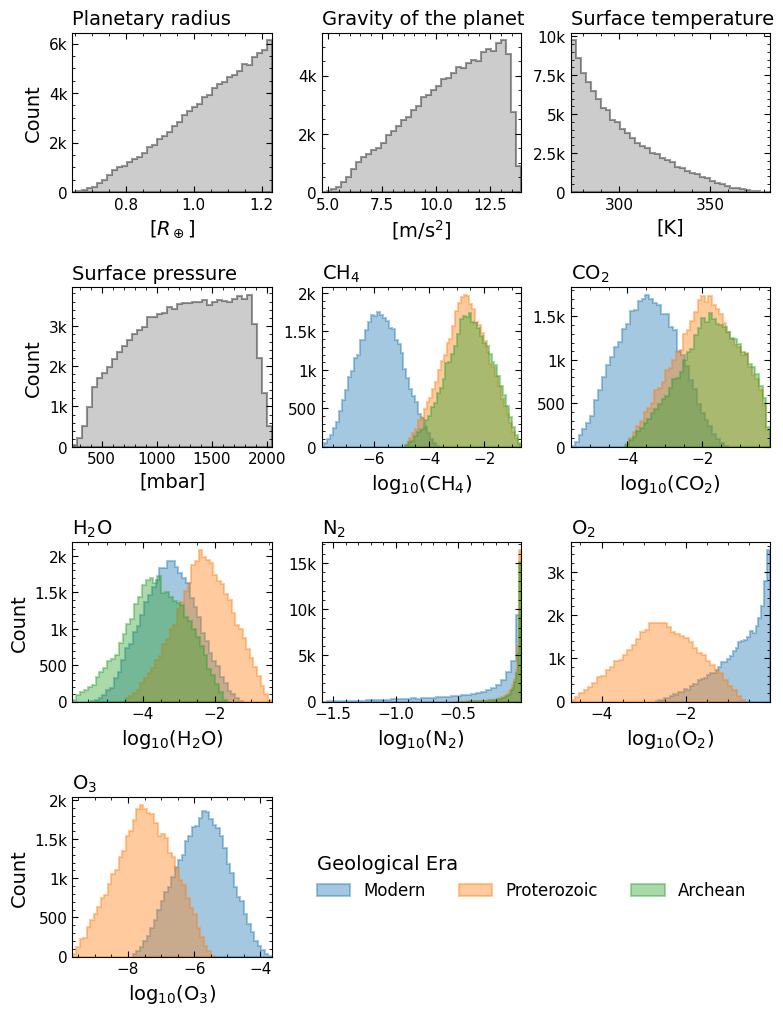

In [19]:
output_path = "../images/parameter_distributions.pdf"
bins = 40

PHYSICAL_PARAMS = [
    "OBJECT-RADIUS-REL-EARTH",
    "OBJECT-GRAVITY",
    "ATMOSPHERE-TEMPERATURE",
    "ATMOSPHERE-PRESSURE",
]
MOLECULES = ["CH4", "CO2", "H2O", "N2", "O2", "O3"]

ERA_COLORS = {
    "modern": "tab:blue",
    "proterozoic": "tab:orange",
    "archean": "tab:green",
}

param_labels = {
    "OBJECT-RADIUS-REL-EARTH": "Planetary radius",
    "OBJECT-GRAVITY": "Gravity of the planet",
    "ATMOSPHERE-TEMPERATURE": "Surface temperature",
    "ATMOSPHERE-PRESSURE": "Surface pressure",
}
param_units = {
    "OBJECT-RADIUS-REL-EARTH": "[$R_\\oplus$]",
    "OBJECT-GRAVITY": "[m/s$^2$]",
    "ATMOSPHERE-TEMPERATURE": "[K]",
    "ATMOSPHERE-PRESSURE": "[mbar]",
}
molecule_labels = {
    "CH4": "CH$_4$",
    "CO2": "CO$_2$",
    "H2O": "H$_2$O",
    "N2": "N$_2$",
    "O2": "O$_2$",
    "O3": "O$_3$",
}

fig, axes = plt.subplots(4, 3, figsize=(9, 12))
axes = axes.flatten()

for i, param in enumerate(PHYSICAL_PARAMS):
    ax = axes[i]
    all_values = pd.to_numeric(df[param], errors="coerce").dropna().to_numpy()

    ax.hist(
        all_values,
        bins=bins,
        alpha=0.4,
        color="gray",
        edgecolor="black",
        histtype="stepfilled",
        lw=1.5,
    )
    ax.set_xlabel(param_units[param])
    ax.set_ylabel("Count" if i % 3 == 0 else "")
    ax.set_title(param_labels[param], loc="left")
    ax.tick_params(axis="both", labelsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_kM_no_trailing_decimal))
    if all_values.size > 0:
        ax.set_xlim(np.min(all_values), np.max(all_values))

for i, molecule in enumerate(MOLECULES):
    flat_idx = 4 + i
    ax = axes[flat_idx]
    all_log_values = []

    for era in ["modern", "proterozoic", "archean"]:
        vals = (
            pd.to_numeric(df.loc[df["Earth_type"] == era, molecule], errors="coerce")
            .dropna()
            .to_numpy()
        )
        vals = vals[vals > 0]

        if vals.size > 0:
            log_vals = np.log10(vals)
            all_log_values.extend(log_vals)
            ax.hist(
                log_vals,
                bins=bins,
                alpha=0.4,
                color=ERA_COLORS[era],
                edgecolor=ERA_COLORS[era],
                histtype="stepfilled",
                lw=1.5,
                label=era.capitalize(),
            )

    ax.set_xlabel(f"log$_{{10}}$({molecule_labels[molecule]})")
    ax.set_ylabel("Count" if flat_idx % 3 == 0 else "")
    ax.set_title(molecule_labels[molecule], loc="left")
    ax.tick_params(axis="both", labelsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_kM_no_trailing_decimal))
    if len(all_log_values) > 0:
        ax.set_xlim(np.min(all_log_values), np.max(all_log_values))

axes[10].axis("off")
legend_elements = [
    Patch(
        facecolor=ERA_COLORS["modern"],
        alpha=0.4,
        edgecolor=ERA_COLORS["modern"],
        label="Modern",
        lw=1.5,
    ),
    Patch(
        facecolor=ERA_COLORS["proterozoic"],
        alpha=0.4,
        edgecolor=ERA_COLORS["proterozoic"],
        label="Proterozoic",
        lw=1.5,
    ),
    Patch(
        facecolor=ERA_COLORS["archean"],
        alpha=0.4,
        edgecolor=ERA_COLORS["archean"],
        label="Archean",
        lw=1.5,
    ),
]
leg = axes[10].legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(-0.1, 0.5),
    title="Geological Era",
    ncols=3,
)
leg.get_title().set_ha("left")
leg._legend_box.align = "left"

axes[11].axis("off")

plt.subplots_adjust(wspace=0.25, hspace=0.6)
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

# EDA

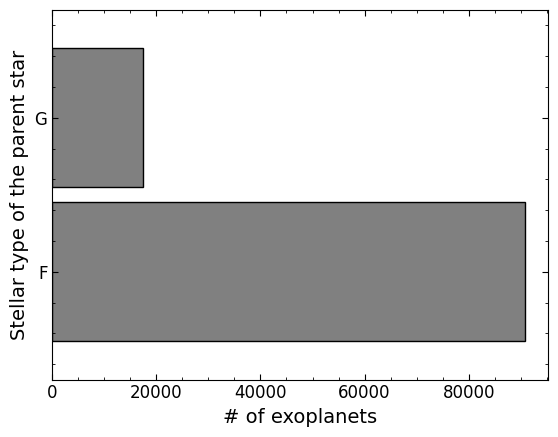

In [22]:
df["OBJECT-STAR-TYPE"].value_counts().plot(kind="barh", ec="k", width=0.9, color="gray")
plt.xticks(rotation=0)
plt.ylabel("Stellar type of the parent star"), plt.xlabel("# of exoplanets")
plt.show()

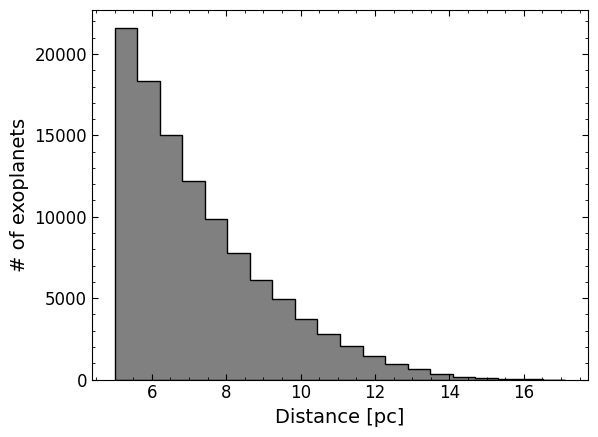

In [27]:
df["GEOMETRY-OBS-ALTITUDE"].hist(
    ec="k", bins=20, histtype="stepfilled", grid=False, color="gray"
)
plt.xlabel("Distance [pc]")
plt.ylabel("# of exoplanets")
plt.show()

# Analysis of noise influence

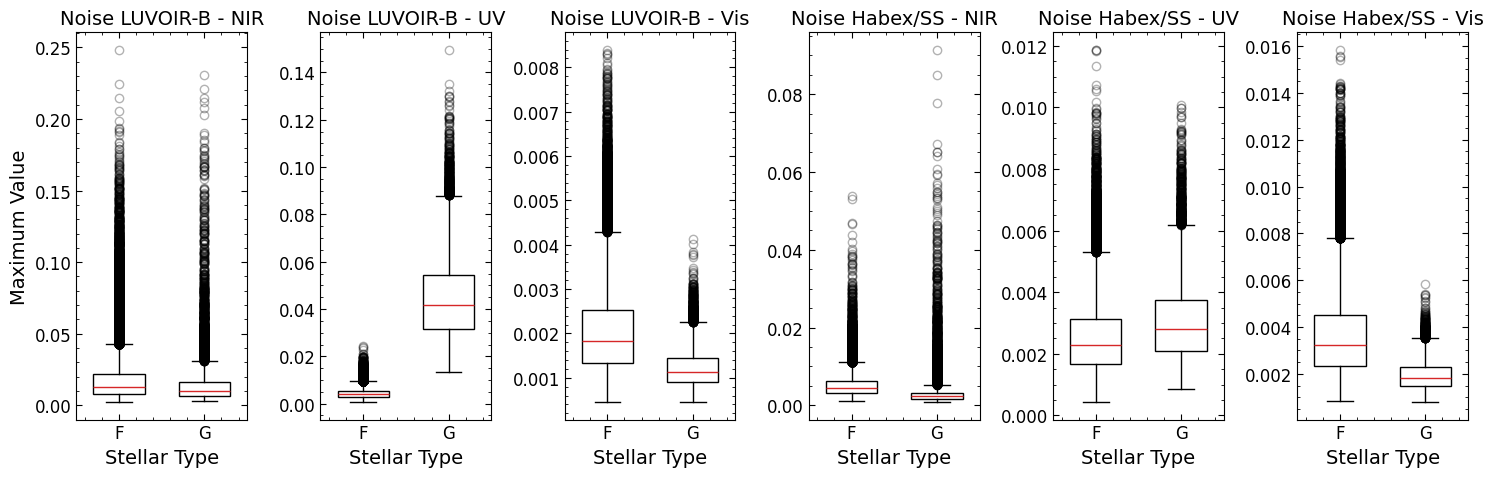

In [31]:
noise_columns = [col for col in df.columns if "NOISE_" in col]
data = df[noise_columns]

title_mapping = {"NOISE_": "Noise ", "B-": "LUVOIR-B - ", "SS-": "Habex/SS - "}

max_values_df = pd.DataFrame(
    {col: data[col].explode().groupby(level=0).max() for col in data.columns}
)

max_values_df["OBJECT-STAR-TYPE"] = df["OBJECT-STAR-TYPE"].values
stellar_types = max_values_df["OBJECT-STAR-TYPE"].unique()

plt.figure(figsize=(15, 5))
for i, col in enumerate(noise_columns):
    plt.subplot(1, len(noise_columns), i + 1)
    for j, stellar_type in enumerate(stellar_types):
        filtered_values = max_values_df[
            max_values_df["OBJECT-STAR-TYPE"] == stellar_type
        ][col]
        bp = plt.boxplot(
            filtered_values.dropna(),
            positions=[j],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor="white", color="k", linewidth=1),
            medianprops=dict(color="tab:red", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1),
            flierprops=dict(marker="o", color="tab:gray", alpha=0.3),
        )

    formatted_title = col
    for key, value in title_mapping.items():
        formatted_title = formatted_title.replace(key, value)
    plt.gcf().axes[i].set_title(formatted_title)

    plt.xticks(range(len(stellar_types)), stellar_types)
    plt.xlabel("Stellar Type")
    plt.ylabel("Maximum Value")

for i, ax in enumerate(plt.gcf().axes):
    if i > 0:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [3]:
split_paths = {
    "train": os.path.join("../data/train.tfrecord"),
    "val": os.path.join("../data/val.tfrecord"),
    "test": os.path.join("../data/test.tfrecord"),
}

telescopes = ["B", "SS"]
bands = ["UV", "Vis", "NIR"]
bases = [f"{tel}-{band}" for tel in telescopes for band in bands]

feature_prefix = "SNR_FEATURE_PCTL_"


def collect_snr_from_tfrecord(tfrecord_path, bases):
    feature_description = {
        feature_prefix + base: tf.io.FixedLenFeature([], tf.float32) for base in bases
    }

    def _parse_fn(example_proto):
        return tf.io.parse_single_example(example_proto, feature_description)

    ds = tf.data.TFRecordDataset(tfrecord_path)
    ds = ds.map(_parse_fn).batch(4096)

    snr_dict = {base: [] for base in bases}

    for batch in ds:
        for base in bases:
            key = feature_prefix + base
            snr_dict[base].append(batch[key].numpy())

    for base in bases:
        if len(snr_dict[base]) > 0:
            snr_dict[base] = np.concatenate(snr_dict[base], axis=0)
        else:
            snr_dict[base] = np.array([])

    return snr_dict


snr_data = {}
for split, path in split_paths.items():
    snr_data[split] = collect_snr_from_tfrecord(path, bases)

for split in split_paths.keys():
    any_base = bases[0]
    print(split, snr_data[split][any_base].shape[0], "samples")

train 86596 samples
val 10824 samples
test 10826 samples


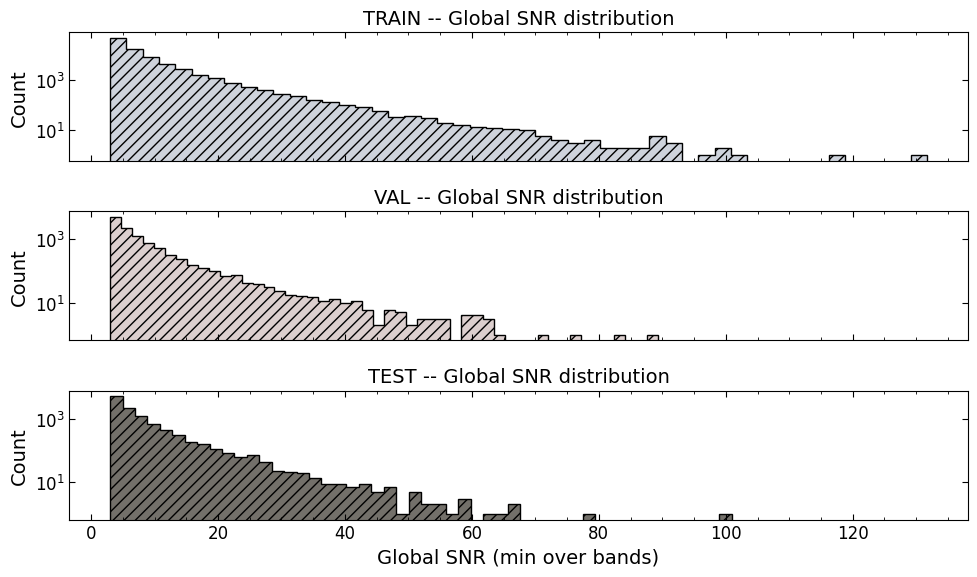

In [5]:
global_snr = {}

colors = {
    "train": "#ced3dc",
    "val": "#dccfce",
    "test": "#73706a",
}

for i, split in enumerate(["train", "val", "test"]):
    mat = np.stack([snr_data[split][base] for base in bases], axis=1)
    global_snr[split] = np.min(mat, axis=1)

fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

for ax, split in zip(axs, ["train", "val", "test"]):
    vals = global_snr[split]

    ax.hist(
        vals,
        bins=50,
        histtype="stepfilled",
        edgecolor="k",
        hatch="///",
        color=colors[split],
    )

    ax.set_yscale("log")
    ax.set_ylabel("Count")
    ax.set_title(f"{split.upper()} -- Global SNR distribution")

axs[-1].set_xlabel("Global SNR (min over bands)")

plt.tight_layout()
plt.show()

In [7]:
rows_global = []
for split in ["train", "val", "test"]:
    vals = global_snr[split]
    rows_global.append(
        {
            "Split": split,
            "Mean": np.mean(vals),
            "Median": np.median(vals),
            "Std": np.std(vals),
            "P5": np.percentile(vals, 5),
            "P50": np.percentile(vals, 50),
            "P95": np.percentile(vals, 95),
            "Min": np.min(vals),
            "Max": np.max(vals),
        }
    )

pd.DataFrame(rows_global).T

,0,1,2
Split,train,val,test
Mean,7.188242,7.178437,7.182544
Median,5.137433,5.118597,5.169688
Std,6.080828,6.126173,5.884478
P5,3.132453,3.142533,3.131454
P50,5.137433,5.118597,5.169688
P95,18.264034,18.16168,18.266947
Min,3.000007,3.00003,3.000006
Max,131.707214,89.33213,100.966095


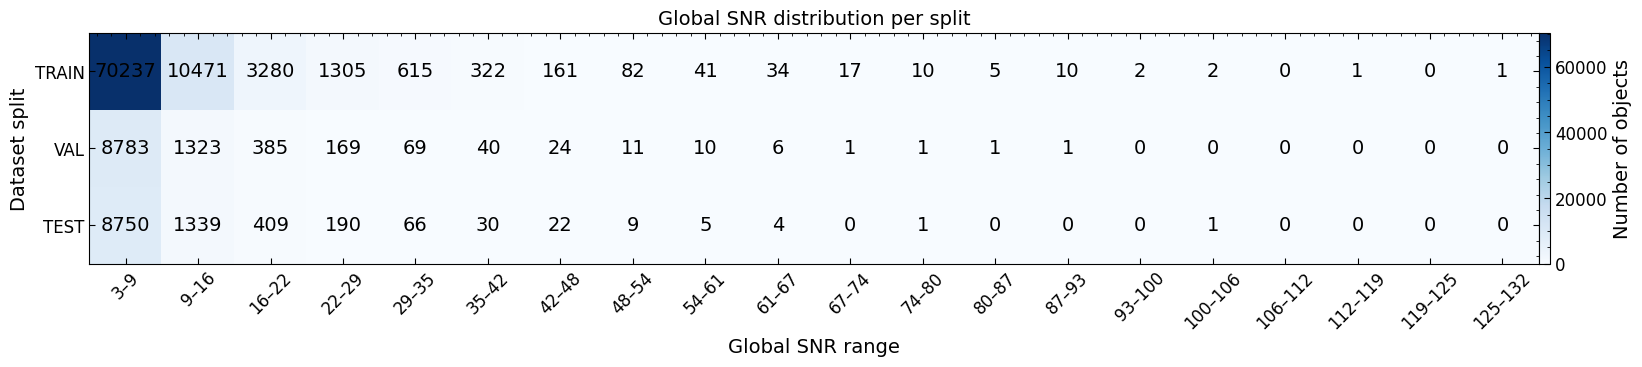

In [21]:
all_vals = np.concatenate([global_snr["train"], global_snr["val"], global_snr["test"]])

vmin, vmax = all_vals.min(), all_vals.max()
n_bins = 20
bins = np.linspace(vmin, vmax, n_bins + 1)

splits = ["train", "val", "test"]
heat = []

for split in splits:
    counts, _ = np.histogram(global_snr[split], bins=bins)
    heat.append(counts)

heat = np.array(heat)

xticks = [f"{bins[i]:.0f}–{bins[i+1]:.0f}" for i in range(len(bins) - 1)]
yticks = [s.upper() for s in splits]

fig, ax = plt.subplots(figsize=(22, 3))

im = ax.imshow(heat, cmap="Blues", aspect="auto")

ax.tick_params(which="minor", bottom=False, left=False)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(
            j,
            i,
            f"{heat[i, j]:d}",
            ha="center",
            va="center",
            color="black",
        )

ax.set_xticks(np.arange(heat.shape[1]))
ax.set_yticks(np.arange(heat.shape[0]))
ax.set_xticklabels(xticks, rotation=45, ha="center")
ax.set_yticklabels(yticks)

ax.set_xlabel("Global SNR range")
ax.set_ylabel("Dataset split")
ax.set_title("Global SNR distribution per split")

cbar = fig.colorbar(im, ax=ax, pad=0)
cbar.set_label("Number of objects")
plt.show()

# Data distribution (paper tables)

In [34]:
features = [
    "OBJECT-RADIUS-REL-EARTH",
    "OBJECT-GRAVITY",
    "ATMOSPHERE-TEMPERATURE",
    "ATMOSPHERE-PRESSURE",
    "CH4",
    "CO2",
    "H2O",
    "N2",
    "O2",
    "O3",
]


def to_sci_notation(x):
    if pd.isna(x):
        return "NaN"
    if x <= 0:
        return "0"
    return np.format_float_scientific(x, precision=10, unique=True)


data = []
for et in ["modern", "proterozoic", "archean"]:
    sub = df[df["Earth_type"] == et]

    for feature in features:
        vals = pd.to_numeric(sub[feature], errors="coerce").dropna().to_numpy()
        if vals.size == 0:
            min_val, max_val = np.nan, np.nan
        else:
            min_val, max_val = np.min(vals), np.max(vals)

        data.append(
            {
                "Earth Type": et,
                "Feature": feature,
                "Min": to_sci_notation(min_val),
                "Max": to_sci_notation(max_val),
            }
        )

df_stats = pd.DataFrame(data)

for et in df_stats["Earth Type"].unique():
    print(f">> {et.upper()}")
    display(df_stats[df_stats["Earth Type"] == et].iloc[:, 1:])

>> MODERN


,Feature,Min,Max
0,OBJECT-RADIUS-REL-EARTH,6.4401346445e-01,1.2299998999e+00
1,OBJECT-GRAVITY,4.7215871811e+00,1.3928157806e+01
2,ATMOSPHERE-TEMPERATURE,2.7315008545e+02,3.8173019409e+02
3,ATMOSPHERE-PRESSURE,2.4713993835e+02,2.0423999023e+03
4,CH4,1.2411314643e-08,2.2106363031e-04
5,CO2,3.0394664918e-06,4.8720758408e-02
6,H2O,3.7040144889e-06,5.8760832995e-02
7,N2,2.5481102988e-02,9.9805730581e-01
8,O2,1.9006675575e-03,9.7425144911e-01
9,O3,1.4122496061e-08,2.1914199169e-04


>> PROTEROZOIC


,Feature,Min,Max
10,OBJECT-RADIUS-REL-EARTH,6.4109259844e-01,1.2299957275e+00
11,OBJECT-GRAVITY,4.7040514946e+00,1.3929901123e+01
12,ATMOSPHERE-TEMPERATURE,2.7315032959e+02,3.8309204102e+02
13,ATMOSPHERE-PRESSURE,2.3401081848e+02,2.0430812988e+03
14,CH4,1.5263552996e-05,2.1447652578e-01
15,CO2,8.8698405307e-05,6.2946248055e-01
16,H2O,3.3965501643e-05,3.6799129844e-01
17,N2,2.9156470299e-01,9.9978351593e-01
18,O2,1.8507998902e-05,2.5410735607e-01
19,O3,2.093385465e-10,4.0597074076e-06


>> ARCHEAN


,Feature,Min,Max
20,OBJECT-RADIUS-REL-EARTH,6.4533001184e-01,1.2299991846e+00
21,OBJECT-GRAVITY,4.8241724968e+00,1.3924687386e+01
22,ATMOSPHERE-TEMPERATURE,2.7315017700e+02,3.8043069458e+02
23,ATMOSPHERE-PRESSURE,2.3856341553e+02,2.0445938721e+03
24,CH4,1.3453502106e-05,2.0729708672e-01
25,CO2,8.8341606897e-05,6.3563001156e-01
26,H2O,1.1388025314e-06,2.096776478e-02
27,N2,3.0580931902e-01,9.9977707863e-01
28,O2,0,0
29,O3,0,0


# How many planets can retain atmospheres?

In [37]:
spectral_type = ["F", "G"]
params = {
    "F": {
        "temp_range": (6000, 7220),
        "radius_range": (1.18, 1.79),
        "mag_range": (2.50, 4.22),
    },
    "G": {
        "temp_range": (5340, 5920),
        "radius_range": (0.876, 1.12),
        "mag_range": (4.40, 5.34),
    },
}


def simulate_planet():
    class_star = np.random.choice(spectral_type)
    star_temperature = round(np.random.uniform(*params[class_star]["temp_range"]), 3)
    star_radius = round(np.random.uniform(*params[class_star]["radius_range"]), 3)

    temp = star_temperature - 5780
    star_luminosity = (
        4
        * np.pi
        * (star_radius * R_sun.value) ** 2
        * sigma_sb.value
        * star_temperature**4
    )

    S_eff_odot = 1.776
    a, b, c, d = 2.136e-4, 2.533e-8, -1.332e-11, -3.097e-15
    S_eff_lower = S_eff_odot + a * temp + b * temp**2 + c * temp**3 + d * temp**4

    S_eff_odot = 0.32
    a, b, c, d = 5.547e-5, 1.526e-9, -2.874e-12, -5.011e-16
    S_eff_upper = S_eff_odot + a * temp + b * temp**2 + c * temp**3 + d * temp**4
    lower_dist = np.sqrt((star_luminosity / L_sun.value) / S_eff_lower)
    upper_dist = np.sqrt((star_luminosity / L_sun.value) / S_eff_upper)
    semi_major_axis = np.random.uniform(lower_dist, upper_dist)

    planet_radius = np.random.uniform(0.3, 1.23)
    planet_mass = planet_radius ** (1 / (0.279 + np.random.uniform(-0.009, 0.009)))
    gravity = (
        G.value * (planet_mass * M_earth.value) / (planet_radius * R_earth.value) ** 2
    )
    escape_velocity = np.sqrt(2 * gravity * planet_radius * R_earth.value)

    real_insolation = (1**2 / semi_major_axis**2) * (star_luminosity / L_sun.value)
    cosmic_shoreline = (5 * 1e-16) * (escape_velocity) ** 4

    return real_insolation < cosmic_shoreline


n = 100000


def run_simulations(n=n):
    count_atmosphere = 0
    count_no_atmosphere = 0

    for _ in range(n):
        if simulate_planet():
            count_atmosphere += 1
        else:
            count_no_atmosphere += 1

    return count_atmosphere, count_no_atmosphere


count_atmosphere, count_no_atmosphere = run_simulations()
print(
    f"Planets with atmosphere: {count_atmosphere} ({(count_atmosphere / n) * 100:.2f}%)"
)
print(
    f"Planets without atmosphere: {count_no_atmosphere} ({(count_no_atmosphere / n) * 100:.2f}%)"
)

Planets with atmosphere: 64514 (64.51%)
Planets without atmosphere: 35486 (35.49%)


In [4]:
def calculate_boiling_point(pressure_mbar):
    P0 = 1013.25  # Reference pressure (1 atm in mbar)
    T0 = 373.15  # Boiling point of water at 1 atm (in K)
    Hv = 40.65 * 1e3  # Latent heat of vaporization (in J/mol)
    return 1 / ((1 / T0) - (R.value / Hv) * np.log(pressure_mbar / P0))


def simulate_planet():
    spectral_type = ["F", "G"]
    class_star = np.random.choice(spectral_type)

    params = {
        "F": {
            "temp_range": (6000, 7220),
            "radius_range": (1.18, 1.79),
            "mag_range": (2.50, 4.22),
        },
        "G": {
            "temp_range": (5340, 5920),
            "radius_range": (0.876, 1.12),
            "mag_range": (4.40, 5.34),
        },
    }

    star_temperature = round(np.random.uniform(*params[class_star]["temp_range"]), 3)
    star_radius = round(np.random.uniform(*params[class_star]["radius_range"]), 3)
    star_luminosity = (
        4
        * np.pi
        * (star_radius * R_sun.value) ** 2
        * sigma_sb.value
        * star_temperature**4
    )

    temp = star_temperature - 5780

    # Recent Venus (lower limit)
    S_eff_odot = 1.776
    a, b, c, d = 2.136e-4, 2.533e-8, -1.332e-11, -3.097e-15
    S_eff_lower = S_eff_odot + a * temp + b * temp**2 + c * temp**3 + d * temp**4

    # Early Mars (upper limit)
    S_eff_odot = 0.32
    a, b, c, d = 5.547e-5, 1.526e-9, -2.874e-12, -5.011e-16
    S_eff_upper = S_eff_odot + a * temp + b * temp**2 + c * temp**3 + d * temp**4

    # Distance of the habitable zone
    lower_dist = np.sqrt((star_luminosity / L_sun.value) / S_eff_lower)
    upper_dist = np.sqrt((star_luminosity / L_sun.value) / S_eff_upper)
    semi_major_axis = np.random.uniform(lower_dist, upper_dist)

    # Planet properties
    planet_radius = np.random.uniform(0.3, 1.23)
    planet_mass = planet_radius ** (1 / (0.279 + np.random.uniform(-0.009, 0.009)))
    gravity = (
        G.value * (planet_mass * M_earth.value) / (planet_radius * R_earth.value) ** 2
    )
    escape_velocity = np.sqrt(2 * gravity * planet_radius * R_earth.value)
    real_insolation = (1**2 / semi_major_axis**2) * (star_luminosity / L_sun.value)
    cosmic_shoreline = (5 * 1e-16) * (escape_velocity) ** 4

    if real_insolation < cosmic_shoreline:
        # Atmosphere and temperature
        albedo = np.random.uniform(0.06, 0.96)
        emissivity = 1 - albedo
        pressure_mbar = 1013.25 * (
            planet_radius ** (3.168 + np.random.uniform(-0.232, 0.232))
        )
        teq = ((1 - albedo) * (real_insolation * 1361.0) / (4 * sigma_sb.value)) ** (
            1 / 4
        )
        temperature_analogue = teq * (2 / (2 - emissivity)) ** (1 / 4)

        boiling_point = calculate_boiling_point(pressure_mbar)
        freezing_point = 273.15 if pressure_mbar * 100 > 611.657 else None

        if freezing_point is None:
            return "Water sublimates (solid state to gaseous state)"

        if freezing_point and freezing_point <= temperature_analogue <= boiling_point:
            return "Planet supports liquid water."
        elif temperature_analogue > boiling_point:
            return "The planet is boiling!"
        elif temperature_analogue < 273.15:
            return "THe planet is freezing!"
    else:
        return "Planet cannot retain atmosphere."


results = {
    "Water sublimates (solid state to gaseous state)": 0,
    "Planet supports liquid water.": 0,
    "The planet is boiling!": 0,
    "THe planet is freezing!": 0,
    "Planet cannot retain atmosphere.": 0,
}

for _ in range(100_000):
    outcome = simulate_planet()
    if outcome in results:
        results[outcome] += 1

total = sum(results.values())
percentages = {key: (value / total) * 100 for key, value in results.items()}
for key, value in results.items():
    print(f"{key}: {value} ({percentages[key]:.2f}%)")

Water sublimates (solid state to gaseous state): 0 (0.00%)
Planet supports liquid water.: 10895 (10.90%)
The planet is boiling!: 95 (0.10%)
THe planet is freezing!: 53661 (53.66%)
Planet cannot retain atmosphere.: 35349 (35.35%)
